# <b><u>Alzheimer’s Research project ▶ ❤</u><b>
## Introduction


In [ ]:
# Ensure pyarrow is installed in this kernel
!pip install --quiet pyarrow
!pip install pandas Pillow kagglehub ipywidgets numpy matplotlib pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.3 MB/s eta 0:00:00


In [1]:
import pandas as pd
from PIL import Image
import io
import numpy as np
import os
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights, ResNet34_Weights # Added import
from torch.utils.data import DataLoader, Dataset
import glob
import random

### <b>1) Load Dataset<b>

In [3]:
from google.colab import drive
drive.mount('/content/Alzheimer_Data')
data_path = "/content/Alzheimer_Data/MyDrive/Alzheimer_Data"


Mounted at /content/Alzheimer_Data


In [4]:
# Load parquet files
# Make sure to reference download instructions. You have to download the kaggle dataset and upload it, rename it to a data directory. Video guide coming soon
#from: https://drive.google.com/drive/folders/12-1XR8df-rYkwJuMqMgXYQ9dm6EoDx0f?usp=drive_link
#quickstart guide: https://www.youtube.com/watch?v=WPRarAeelAM
#Original source + description: https://advp.niagads.org/downloads
train_data_path = data_path + "/Train_data/train.parquet"
test_data_path = data_path + "/Test_data/test.parquet"
train_df = pd.read_parquet(train_data_path)
test_df  = pd.read_parquet(test_data_path)

def bytes_to_pixels(b: bytes) -> np.ndarray:
    """
    Convert raw image bytes (e.g. JPEG/PNG) into a 2D numpy array of pixel values (grayscale).
    """
    img = Image.open(io.BytesIO(b))  # convert to grayscale
    return np.array(img)
def extract_bytes(blob):
    """
    Unwrap a dict‐wrapped binary payload if needed,
    otherwise return blob directly.
    """
    if isinstance(blob, dict):
        # try common keys
        for key in ("bytes", "data", "image"):
            if key in blob and isinstance(blob[key], (bytes, bytearray)):
                return blob[key]
        # fallback: first bytes‐like value
        for v in blob.values():
            if isinstance(v, (bytes, bytearray)):
                return v
        raise TypeError(f"No bytes found in dict payload: {list(blob.keys())}")
    return blob

train_df["image"] = train_df["image"].apply(lambda blob: bytes_to_pixels(extract_bytes(blob)))
test_df["image"]  = test_df["image"].apply(lambda blob: bytes_to_pixels(extract_bytes(blob)))


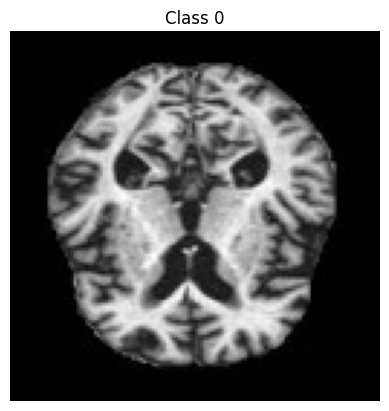

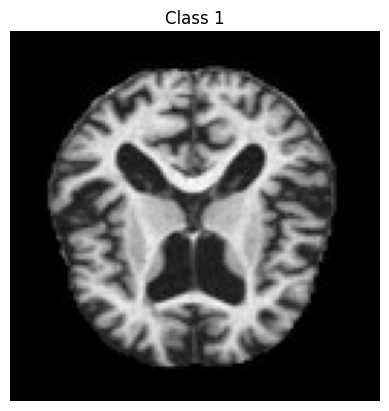

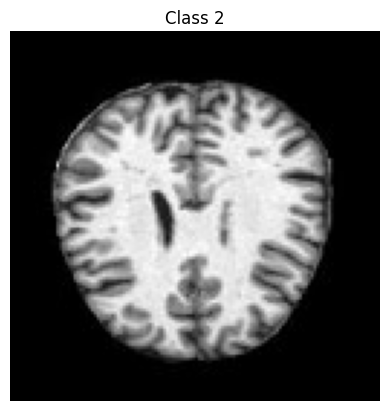

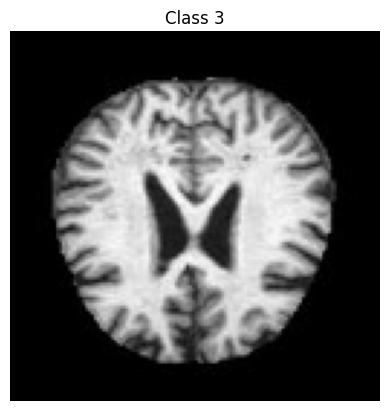

In [5]:
# First Visualization
for label in sorted(train_df["label"].unique()):
    sample = train_df[train_df["label"] == label].sample(1)
    plt.imshow(sample["image"].values[0], cmap="gray")
    plt.title(f"Class {label}")
    plt.axis("off")
    plt.show()

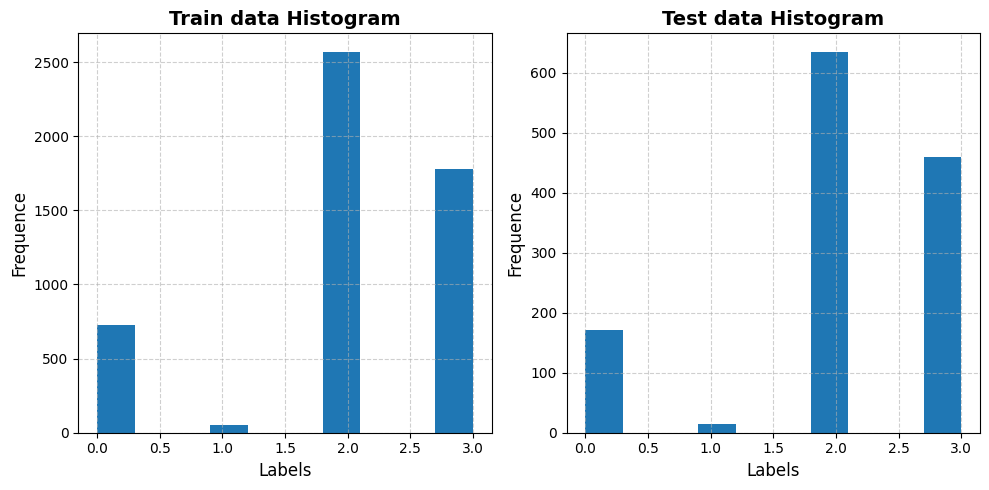

In [7]:
# Analysis of our dataset
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(train_df['label'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Labels', fontsize=12)
plt.ylabel('Frequence', fontsize=12)
plt.title("Train data Histogram", fontsize=14, fontweight='bold')
plt.subplot(1,2,2)
plt.hist(test_df['label'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Labels', fontsize=12)
plt.ylabel('Frequence', fontsize=12)
plt.title("Test data Histogram", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/images/TainTestDataHistograms.png", dpi=300)
plt.show()

In [8]:
print("Train images shape :",train_df["image"].shape)
print("Test images shape :",test_df["image"].shape)
print("Image shape: ",train_df["image"][0].shape)

Train images shape : (5120,)
Test images shape : (1280,)
Image shape:  (128, 128)


1. label = 2


/tmp/ipython-input-4051836937.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels.astype("uint8"), mode="L")


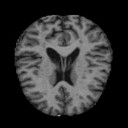

2. label = 0


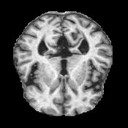

3. label = 3


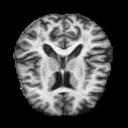

4. label = 3


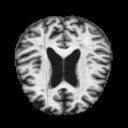

5. label = 2


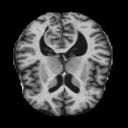

6. label = 2


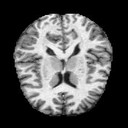

7. label = 2


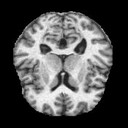

8. label = 2


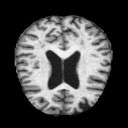

9. label = 3


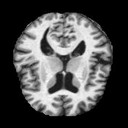

10. label = 2


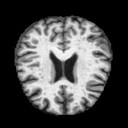

In [9]:
def display_images(df, n=10):
    """
    Display the first n grayscale images (numpy arrays) from df
    along with their labels. Assumes df has columns 'image' and 'label'.
    """
    for i, (_, row) in enumerate(df.head(n).iterrows(), start=1):
        pixels = row["image"]
        label = row.get("label", "")
        # Create a PIL image in 'L' mode (8-bit pixels, black and white)
        img = Image.fromarray(pixels.astype("uint8"), mode="L")
        print(f"{i}. label = {label}")
        display(img)
display_images(train_df)

### <b>2) Model design<b>

In [10]:
#                  Model architecture MultiScaleFastFlow
#--------------------------------------------------------

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)
        attn = torch.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))
        return x * attn

# -------------------------------------------------
# 1. Multi-scale Feature Extractor (ResNet18)
# -------------------------------------------------
class MultiScaleFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        layers = list(backbone.children())

        self.stem = nn.Sequential(*layers[:4])   # conv1 + bn + relu + maxpool
        self.layer1 = layers[4]                  # 64
        self.layer2 = layers[5]                  # 128
        self.layer3 = layers[6]                  # 256
        self.layer4 = layers[7]                  # 512

        self.attn2 = SpatialAttention()
        self.attn3 = SpatialAttention()
        self.attn4 = SpatialAttention()

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)

        f2 = self.attn2(self.layer2(x))   # (B,128,H/8,W/8)
        f3 = self.attn3(self.layer3(f2))  # (B,256,H/16,W/16)
        f4 = self.attn4(self.layer4(f3))  # (B,512,H/32,W/32)

        return f2, f3, f4


# ---------------------------------------------------------------
# 2. Feature Reducer + Cross Scale Fusion + ResidualReducer
# ---------------------------------------------------------------
class FeatureReducer(nn.Module):
    def __init__(self, in_channels, out_channels, num_groups=32):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.norm = nn.GroupNorm(
            num_groups=min(num_groups, out_channels),
            num_channels=out_channels,
            affine=False
        )

    def forward(self, x):
        x = self.proj(x)
        return self.norm(x)

class CrossScaleFusion(nn.Module):
    def __init__(self):
        super().__init__()
        # Project channels for alignment
        self.proj_f4_to_f3 = nn.Conv2d(512, 256, kernel_size=1)
        self.proj_f3_to_f2 = nn.Conv2d(256, 128, kernel_size=1)

    def forward(self, f2, f3, f4):
        # f4 -> f3
        f4_up = F.interpolate(
            f4, size=f3.shape[-2:], mode="bilinear", align_corners=False
        )
        f4_up = self.proj_f4_to_f3(f4_up)
        f3 = f3 + f4_up

        # f3 -> f2
        f3_up = F.interpolate(
            f3, size=f2.shape[-2:], mode="bilinear", align_corners=False
        )
        f3_up = self.proj_f3_to_f2(f3_up)
        f2 = f2 + f3_up

        return f2, f3, f4

class ResidualReducer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1),
            nn.GroupNorm(32, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(32, out_channels)
        )

    def forward(self, x):
        x = self.net(x)

        # Spatial standardization (per sample, per channel)
        mean = x.mean(dim=(2, 3), keepdim=True)
        std = x.std(dim=(2, 3), keepdim=True) + 1e-6
        x = (x - mean) / std

        return x



# -------------------------------------------------
# 3. Invertible 1x1 Convolution (Glow)
# -------------------------------------------------
class Invertible1x1Conv(nn.Module):
    def __init__(self, channels):
        super().__init__()
        w = torch.linalg.qr(torch.randn(channels, channels)).Q
        self.weight = nn.Parameter(w)

    def forward(self, x):
        B, C, H, W = x.shape
        weight = self.weight.view(C, C, 1, 1)
        z = F.conv2d(x, weight)
        log_det = H * W * torch.slogdet(self.weight)[1]
        return z, log_det

    def inverse(self, z):
        C = z.size(1)
        w_inv = torch.inverse(self.weight).view(C, C, 1, 1)
        return F.conv2d(z, w_inv)


# -------------------------------------------------
# 4. Affine Coupling Layer
# -------------------------------------------------
class AffineCoupling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels // 2, channels, 3, padding=1),
            nn.GroupNorm(32, channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(32, channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        xa, xb = x.chunk(2, dim=1)
        h = self.net(xa)
        shift, log_scale = h.chunk(2, dim=1)
        log_scale = torch.tanh(log_scale) * 2.0
        zb = xb * torch.exp(log_scale) + shift
        z = torch.cat([xa, zb], dim=1)
        log_det = log_scale.mean(dim=(1, 2, 3))
        return z, log_det

    def inverse(self, z):
        za, zb = z.chunk(2, dim=1)
        h = self.net(za)
        shift, log_scale = h.chunk(2, dim=1)
        log_scale = torch.tanh(log_scale) * 2.0
        xb = (zb - shift) * torch.exp(-log_scale)
        return torch.cat([za, xb], dim=1)

# -------------------------------------------------
# 5. FastFlow Block
# -------------------------------------------------
class FastFlow(nn.Module):
    def __init__(self, channels, num_blocks):
        super().__init__()
        self.blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.blocks.append(Invertible1x1Conv(channels))
            self.blocks.append(AffineCoupling(channels))

    def forward(self, x):
        B = x.size(0)
        log_det = torch.zeros(B, device=x.device)

        for block in self.blocks:
            x, ld = block(x)
            log_det += ld

        return x, log_det

    def anomaly_map(self, x):
        z, log_det = self.forward(x)
        energy = (z ** 2).sum(dim=1)
        energy = (energy - energy.mean()) / (energy.std() + 1e-6)
        return energy + log_det.view(-1, 1, 1)




# -------------------------------------------------
# 6. Full Multiscale FastFlow Model
# -------------------------------------------------
class MultiScaleFastFlow(nn.Module):
    def __init__(self, flow_channels=128):
        super().__init__()

        self.extractor = MultiScaleFeatureExtractor()
        self.fusion = CrossScaleFusion()

        self.reducers = nn.ModuleList([
            ResidualReducer(128, flow_channels),
            ResidualReducer(256, flow_channels),
            ResidualReducer(512, flow_channels)
        ])

        self.flows = nn.ModuleList([
            FastFlow(flow_channels, num_blocks=8),   # high-res
            FastFlow(flow_channels, num_blocks=12),  # mid-res
            FastFlow(flow_channels, num_blocks=16)  # low-res
        ])

    def forward(self, x):
        f2, f3, f4 = self.extractor(x)
        f2, f3, f4 = self.fusion(f2, f3, f4)

        features = [f2, f3, f4]
        anomaly_maps = []

        for f, reducer, flow in zip(features, self.reducers, self.flows):
            f = reducer(f)
            amap = flow.anomaly_map(f)
            amap = F.interpolate(
                amap.unsqueeze(1),
                size=x.shape[-2:],
                mode="bilinear",
                align_corners=False
            )
            anomaly_maps.append(amap)

        final_map = torch.mean(torch.cat(anomaly_maps, dim=1), dim=1)
        return final_map


### <b>3) Train the model<b>

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [52]:
num_blocks = 16          # depth of each flow
flow_channels = 128      # reduced channel size (recommended)
model = MultiScaleFastFlow(flow_channels=flow_channels).to(device)

Loss_function = []
model_save_path = f"multiscale_fastflow_{num_blocks}blocks_{flow_channels}ch.pth"

In [53]:
# Define normal data for training MultiScaleFastFlow
normal_data = train_df[train_df['label']==3].copy()
image_size_input_train =(128, 128)

In [54]:
class MyDataFrameDataset(Dataset):
  def __init__(self, dataframe, transform=None):
      self.dataframe = dataframe
      self.transform = transform

  def __len__(self):
      return len(self.dataframe)

  def __getitem__(self, idx):
      row = self.dataframe.iloc[idx]
      image_np = row["image"]  # (H, W) numpy array
      image_pil = Image.fromarray(image_np.astype(np.uint8)).convert("RGB")

      if self.transform:
          image = self.transform(image_pil)
      else:
          image = transforms.ToTensor()(image_pil)

      return image

def Dataset_loader(dataset=normal_data, batch_size=32):
  transform = transforms.Compose([
        transforms.Resize(image_size_input_train),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
  dataset = MyDataFrameDataset(normal_data, transform=transform)
  loader_dataset = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
  return loader_dataset

train_loader = Dataset_loader()

In [55]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

In [56]:
# Training our Model

def train(model, loader=train_loader):

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(
                optimizer, step_size=5, gamma=0.9)

    num_epochs = 80

    model.train()

    print("Training started...")
    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for images in loader:
            images = images.to(device)

            optimizer.zero_grad()

            # Forward pass: returns final anomaly map
            anomaly_map = model(images)

            # Loss: minimize anomaly response on normal data
            loss = anomaly_map.mean()

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()

        avg_loss = epoch_loss / len(loader)
        Loss_function.append(avg_loss)

        #print(f"epoch_loss: {epoch_loss}, avg_loss: {avg_loss}, len loader:{len(loader)}")
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.6f}")

    model_save_path = "multiscale_fastflow.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"Training complete. Model saved to {model_save_path}")

if __name__ == "__main__":
    # Train the model
    train(model)

Training started...
Epoch [1/80] | Loss: -3343.976660
Epoch [2/80] | Loss: -10507.614929
Epoch [3/80] | Loss: -18433.353830
Epoch [4/80] | Loss: -27485.434187
Epoch [5/80] | Loss: -38371.636440
Epoch [6/80] | Loss: -52468.812570
Epoch [7/80] | Loss: -69371.647879
Epoch [8/80] | Loss: -75360.648158
Epoch [9/80] | Loss: -77108.659180
Epoch [10/80] | Loss: -79041.909598
Epoch [11/80] | Loss: -80151.043945
Epoch [12/80] | Loss: -80553.026228
Epoch [13/80] | Loss: -81713.894531
Epoch [14/80] | Loss: -82951.596261
Epoch [15/80] | Loss: -83556.963170
Epoch [16/80] | Loss: -83728.749442
Epoch [17/80] | Loss: -84394.202288
Epoch [18/80] | Loss: -84511.808175
Epoch [19/80] | Loss: -85181.943499
Epoch [20/80] | Loss: -85237.069475
Epoch [21/80] | Loss: -85796.281669
Epoch [22/80] | Loss: -85706.162807
Epoch [23/80] | Loss: -86181.640067
Epoch [24/80] | Loss: -87213.393415
Epoch [25/80] | Loss: -87077.807199
Epoch [26/80] | Loss: -86428.635882
Epoch [27/80] | Loss: -86551.076590
Epoch [28/80] | Lo

### <b>4) Evaluate and Test the model<b>

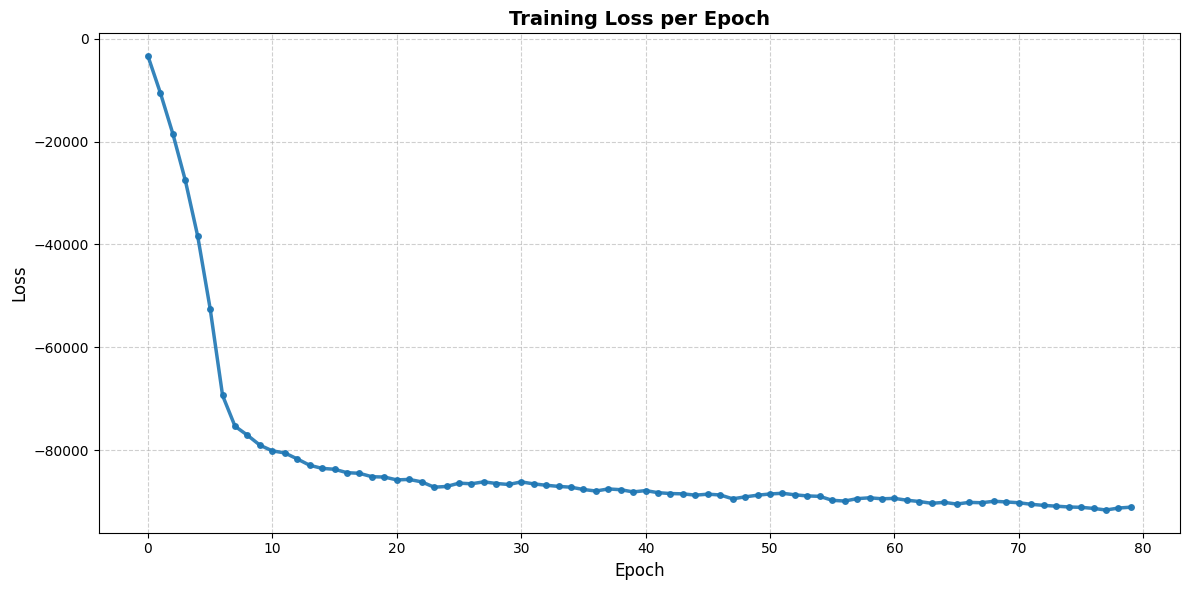

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(Loss_function,linewidth=2.5,marker='o',markersize=4,alpha=0.9)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.title("Training Loss per Epoch", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/images/Loss_function.png", dpi=300)
plt.show()

In [58]:
model = MultiScaleFastFlow(flow_channels=128).to(device)
if os.path.exists(model_save_path):
    print("Loading custom weights...")
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    print("MultiScaleFastFlow weights loaded successfully!")

In [59]:
test_data = test_df
#test_data = train_df[train_df["label"]!=0]

z_max: 10392.333984375
z_min: -9170.9169921875


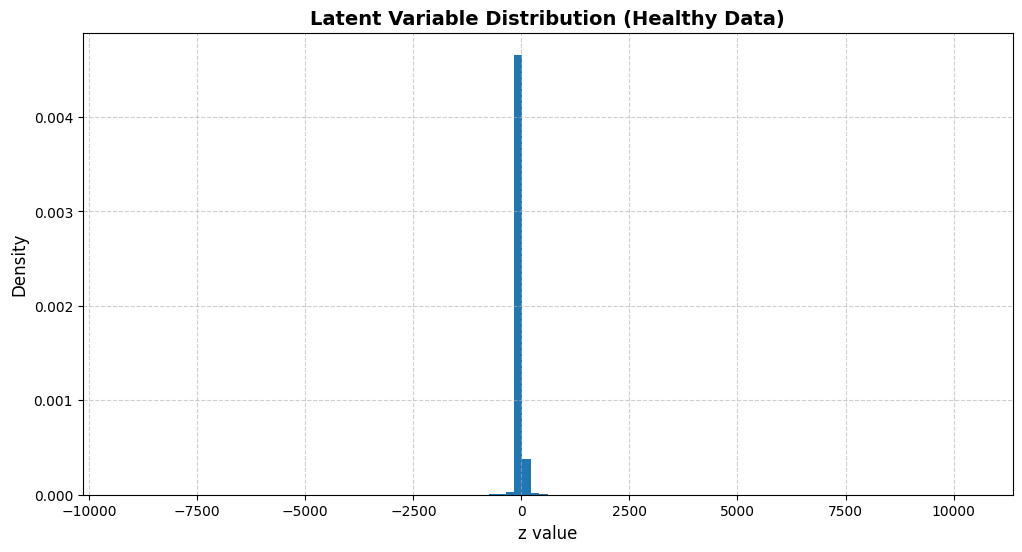

In [60]:
# Plot latent variable distribution

test_loader = Dataset_loader(test_data)
def plot_latent_distribution(model, loader=test_loader, device=device):
    model.eval()
    zs = []
    with torch.no_grad():
        for i, x in enumerate(loader):
            x = x.to(device)
            f2, f3, f4 = model.extractor(x)
            f2, f3, f4 = model.fusion(f2, f3, f4)

            # Use one scale (e.g. mid-scale)
            f = model.reducers[1](f3)
            z, _ = model.flows[1].forward(f)

            zs.append(z.flatten().cpu().numpy())

    zs = np.concatenate(zs)
    print(f"z_max: {zs.max()}\nz_min: {zs.min()}")
    plt.figure(figsize=(12, 6))
    plt.hist(zs, bins=100, density=True)
    plt.title("Latent Variable Distribution (Healthy Data)", fontsize=14, fontweight='bold')
    plt.xlabel("z value", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig("/content/images/Latent_Variable_Distribution_Healthy-Data.png", dpi=300)
    plt.show()
    return zs

zs = plot_latent_distribution(model)


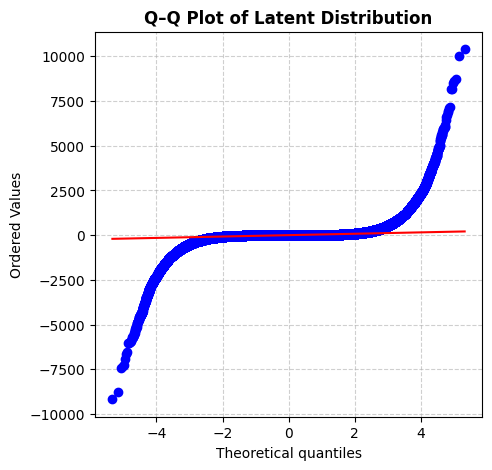

In [61]:
# Q–Q plot vs Gaussian
import scipy.stats as stats

def qq_plot_latent(zs):
    plt.figure(figsize=(5, 5))
    stats.probplot(zs, dist="norm", plot=plt)
    plt.title("Q–Q Plot of Latent Distribution", fontsize=12, fontweight='bold')
    plt.savefig("/content/images/Q-Q_Plot_Latent_Distribution.png", dpi=300)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

qq_plot_latent(zs)

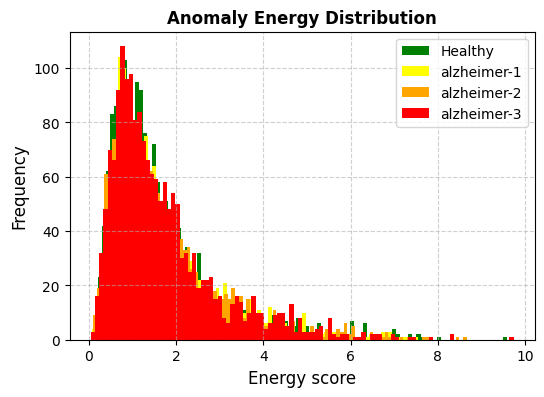

In [62]:
# Plot anomaly or energy score distribution with alzheimer samples
def plot_energy_distribution(model, dataloader=test_loader, device=device, labels=["Healthy"]):

  plt.figure(figsize=(6, 4))
  c = ['green', 'yellow', 'orange', 'red']
  for i, loader_i in enumerate(dataloader):
    model.eval()
    energies = []

    with torch.no_grad():
        for x in loader_i:
            x = x.to(device)
            anomaly_map = model(x)
            anomaly_map = torch.quantile(anomaly_map.view(anomaly_map.size(0), -1), 0.99, dim=1)
            energies.append(anomaly_map.cpu().numpy())

    energies = np.concatenate(energies)

    plt.hist(energies, bins=100, color=c[i], label=labels[i])
    plt.xlabel("Energy score", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

  plt.title("Anomaly Energy Distribution", fontsize=12,fontweight='bold')
  plt.legend()
  plt.savefig("/content/images/plot_energy_distribution.png", dpi=300)
  plt.show()


healthy_loader = Dataset_loader(test_data[test_data['label']==0])
alzheimer_loader1 = Dataset_loader(test_data[test_data['label']==1])
alzheimer_loader2 = Dataset_loader(test_data[test_data['label']==2])
alzheimer_loader3 = Dataset_loader(test_data[test_data['label']==3])

List_loaders = [healthy_loader, alzheimer_loader1, alzheimer_loader2, alzheimer_loader3]
labels_loaders = ['Healthy', 'alzheimer-1', 'alzheimer-2', 'alzheimer-3']

plot_energy_distribution(model, List_loaders, device, labels_loaders)


/tmp/ipython-input-2265783574.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_origin = Image.fromarray(image_np_array.astype(np.uint8),mode="L").convert("RGB")


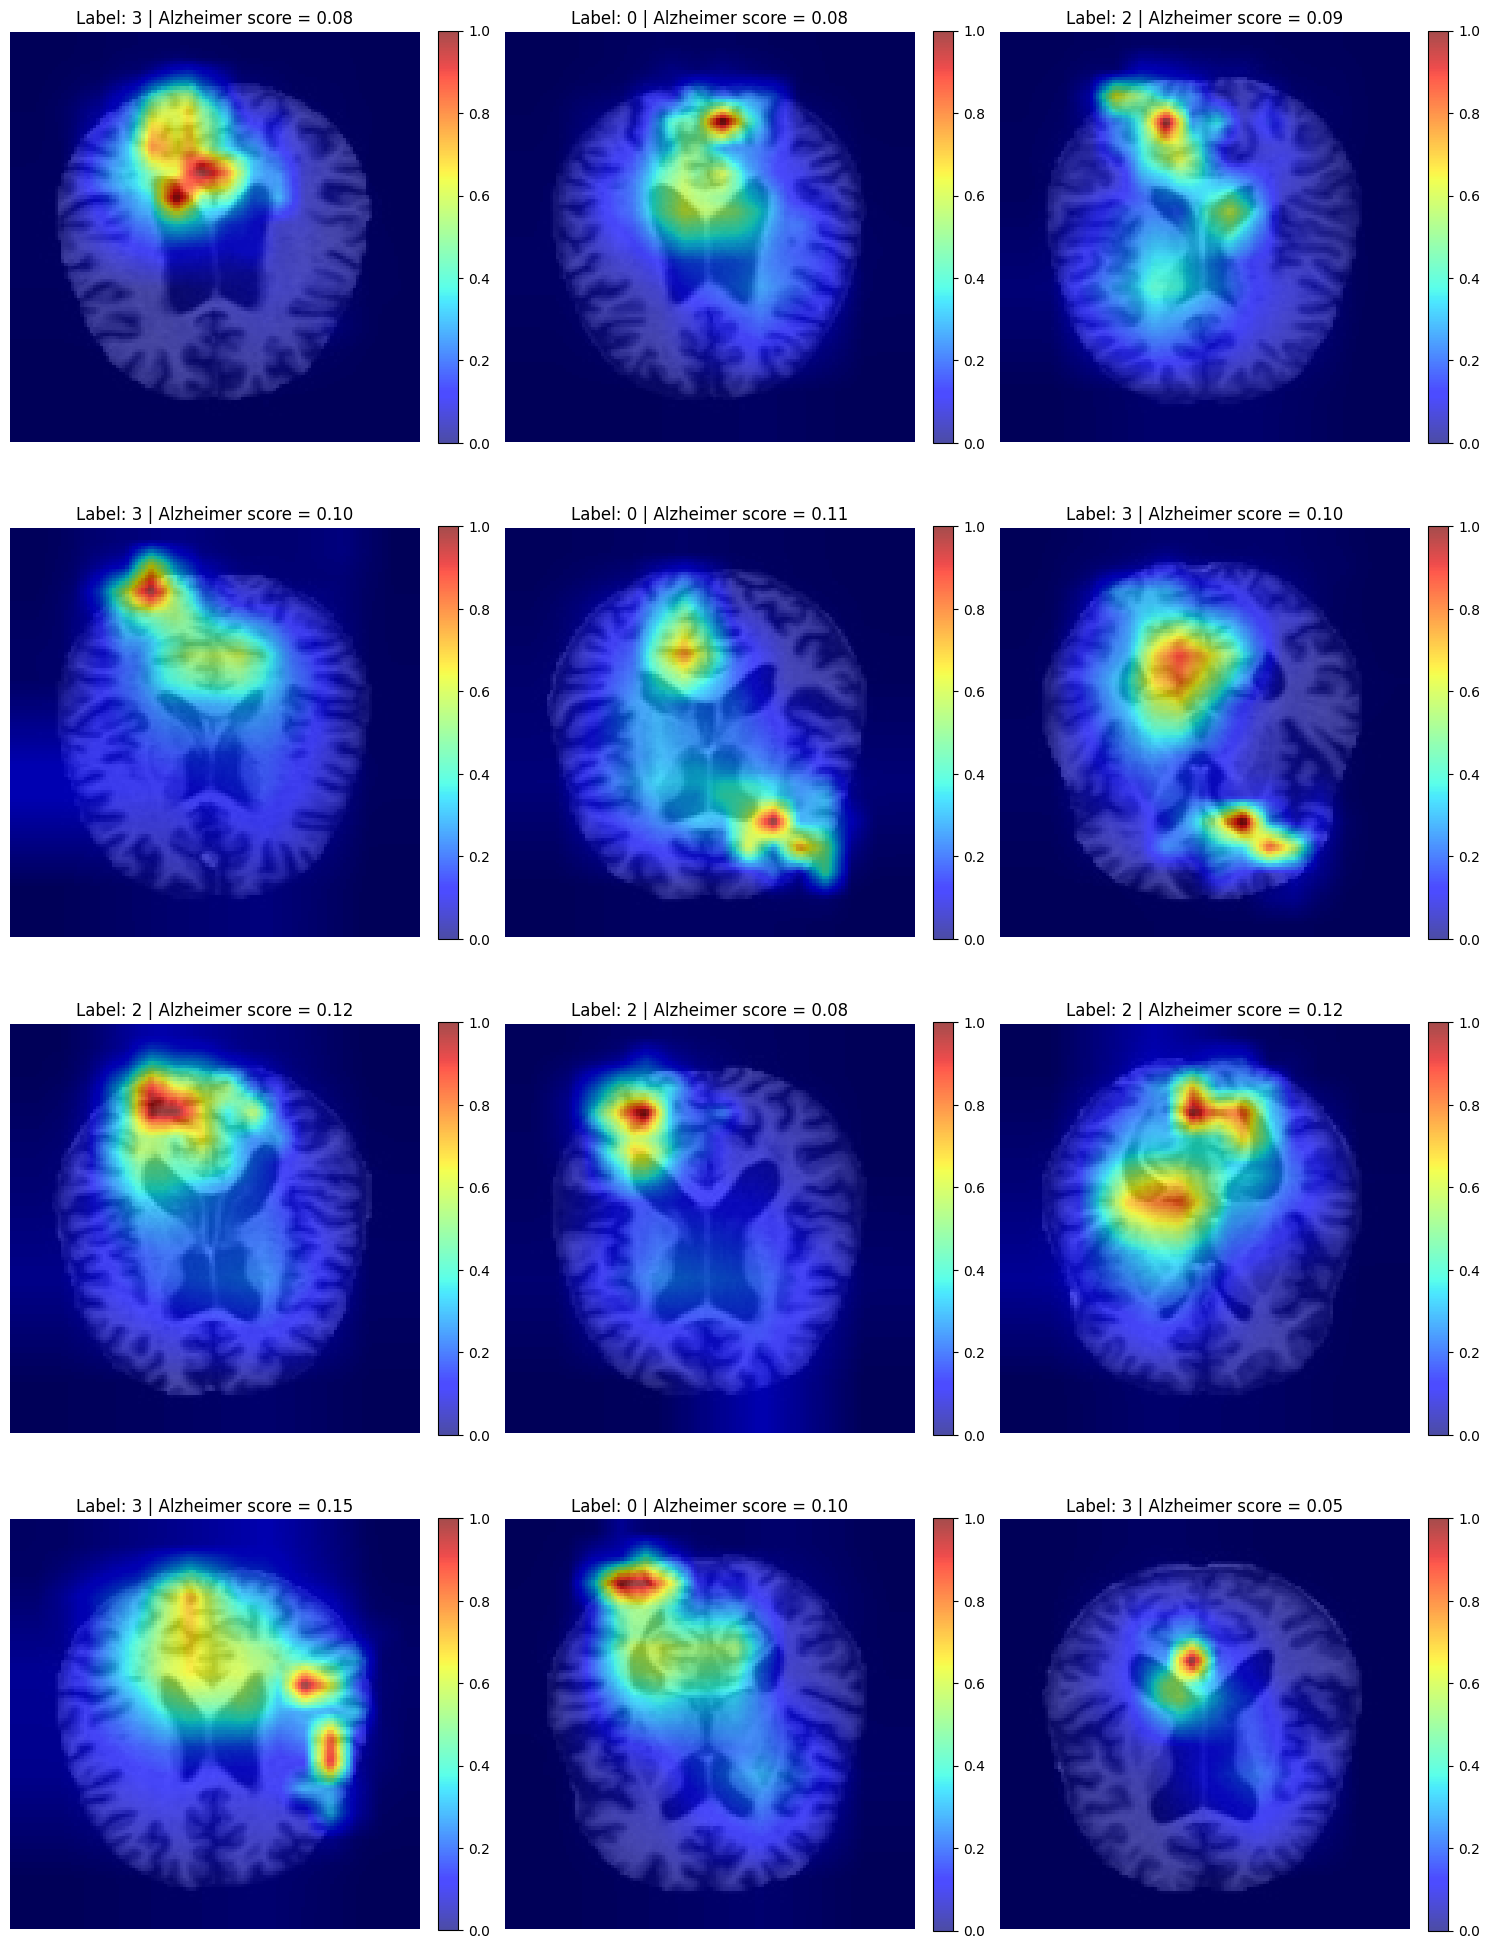

In [63]:
# ----------------------------
# Evaluation & Visualization (Multiscale FastFlow)
# ----------------------------
def evaluate(image_np_array, model):
    transform = transforms.Compose([
        transforms.Resize(image_size_input_train),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])])

    # Convert numpy array → PIL → tensor
    img_origin = Image.fromarray(image_np_array.astype(np.uint8),mode="L").convert("RGB")
    img_tensor = transform(img_origin).unsqueeze(0).to(device)
    model.eval()

    with torch.no_grad():
        # Forward pass through full multiscale model
        anomaly_map = model(img_tensor)  # (1, H, W)

        # Upsample to original resolution
        original_size = img_origin.size[::-1]  # (H, W)
        anomaly_map = F.interpolate(anomaly_map.unsqueeze(1),size=original_size,
                                    mode="bilinear",
                                    align_corners=False).squeeze()
        anomaly_map = anomaly_map.cpu().numpy()

        # Normalize for visualization
        anomaly_map = (anomaly_map - anomaly_map.min()) / (
            anomaly_map.max() - anomaly_map.min())

        anomaly_score = float(anomaly_map.mean())

    # Visualization
    plt.imshow(img_origin)
    plt.imshow(anomaly_map, cmap="jet", alpha=0.7)
    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04)

    return f"{anomaly_score:.2f}"

if __name__ == "__main__":

    num_images = 12
    cols = 3
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(5 * cols, 5 * rows))

    for i, image_np_array in enumerate(test_data["image"]):
        if i < num_images:
            plt.subplot(rows, cols, i + 1)
            score = evaluate(image_np_array, model)

            label = test_data["label"].iloc[i]
            plt.title(f"Label: {label} | Alzheimer score = {score}")
            plt.axis("off")

    plt.tight_layout()
    plt.savefig("/content/images/Visualization_Multiscale_FastFlow.png", dpi=300)
    plt.show()


In [64]:
def evaluate2(image_np_array, model):
    transform = transforms.Compose([
        transforms.Resize(image_size_input_train),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])])

    # Convert numpy array → PIL → tensor
    img_origin = Image.fromarray(image_np_array.astype(np.uint8),mode="L").convert("RGB")
    img_tensor = transform(img_origin).unsqueeze(0).to(device)
    model.eval()

    with torch.no_grad():
        # Forward pass through full multiscale model
        anomaly_map = model(img_tensor)  # (1, H, W)

        # Upsample to original resolution
        original_size = img_origin.size[::-1]  # (H, W)
        anomaly_map = F.interpolate(anomaly_map.unsqueeze(1),size=original_size,
                                    mode="bilinear",
                                    align_corners=False).squeeze()
        anomaly_map = anomaly_map.cpu().numpy()

        # Normalize for visualization
        anomaly_map = (anomaly_map - anomaly_map.min()) / (
            anomaly_map.max() - anomaly_map.min())

        anomaly_score = float(anomaly_map.mean())
        #anomaly_score = float(anomaly_map.mean())

    return round(anomaly_score, 2)

num_images = len(test_data)
new_data_score = []

for i, image_np_array in enumerate(test_data["image"]):
      score = evaluate2(image_np_array, model)
      #label = test_df["label"].iloc[i]
      new_data_score.append(score)

test_data["After_training_score"] =  new_data_score

/tmp/ipython-input-990557702.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_origin = Image.fromarray(image_np_array.astype(np.uint8),mode="L").convert("RGB")


In [65]:
test_data["After_training_score"].head(10)

,After_training_score
0,0.08
1,0.08
2,0.09
3,0.10
4,0.11
5,0.10
6,0.12
7,0.08
8,0.12
9,0.15


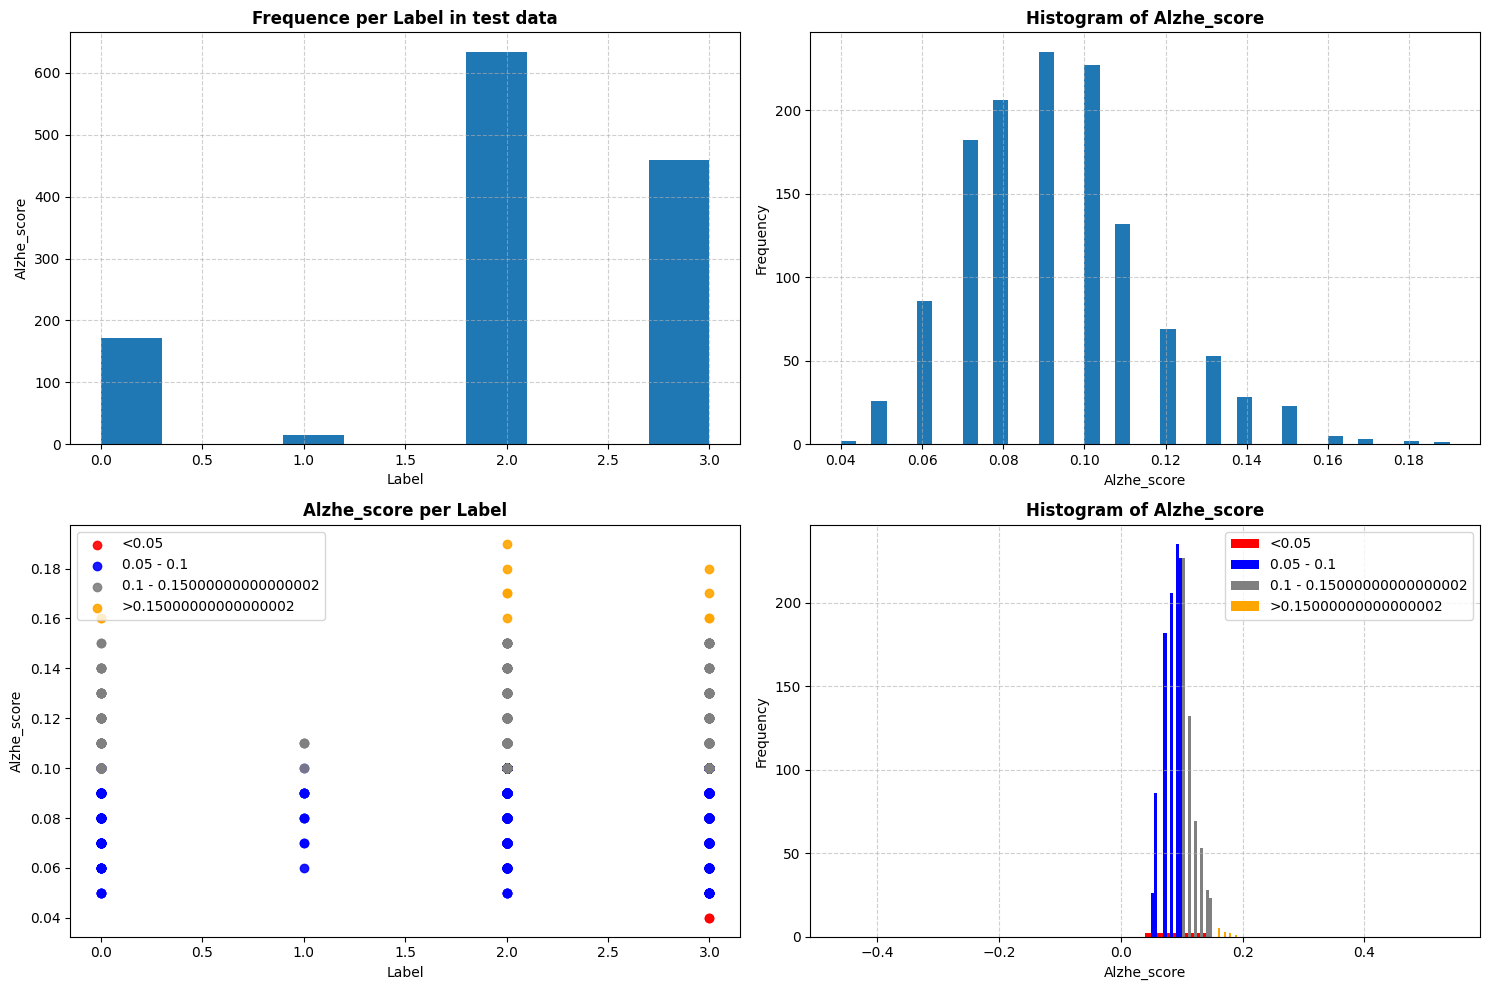

In [66]:
Max_value = round(test_data["After_training_score"].max()/4, 2)
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.hist(test_data["label"],bins=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Label")
plt.ylabel("Alzhe_score")
plt.title("Frequence per Label in test data",fontsize=12, fontweight='bold')
plt.subplot(2,2,2)
plt.hist(test_data["After_training_score"],bins=40)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Alzhe_score")
plt.ylabel("Frequency")
plt.title("Histogram of Alzhe_score",fontsize=12, fontweight='bold')
plt.subplot(2,2,3)
A = test_data[test_data["After_training_score"]<Max_value]  #0.1]
B = test_data[test_data["After_training_score"].between(Max_value, 2*Max_value)]   #.between(0.1, 0.2)]
C = test_data[test_data["After_training_score"].between(2*Max_value, 3*Max_value)]   #.between(0.2, 0.3)]
D = test_data[test_data["After_training_score"]>3*Max_value] #0.3]
plt.scatter(A["label"], A["After_training_score"], alpha=0.9, c="red")
plt.scatter(B["label"], B["After_training_score"],alpha=0.9, c="blue")
plt.scatter(C["label"], C["After_training_score"],alpha=0.9, c="grey")
plt.scatter(D["label"], D["After_training_score"],alpha=0.9, c="orange")
plt.xlabel("Label")
plt.ylabel("Alzhe_score")
plt.title("Alzhe_score per Label",fontsize=12, fontweight='bold')
plt.legend(["<"+str(Max_value),
            str(Max_value)+" - "+str(2*Max_value),
            str(2*Max_value)+" - "+str(3*Max_value),
            ">"+str(3*Max_value)]) #(["<0.1","0.1-0.2","0.2-0.3",">0.3"])
plt.subplot(2,2,4)
plt.hist(A["After_training_score"],bins=10, color="red")
plt.hist(B["After_training_score"],bins=10, color="blue")
plt.hist(C["After_training_score"],bins=10, color="grey")
plt.hist(D["After_training_score"],bins=10, color="orange")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Alzhe_score")
plt.ylabel("Frequency")
plt.title("Histogram of Alzhe_score",fontsize=12, fontweight='bold')
plt.legend(["<"+str(Max_value),
            str(Max_value)+" - "+str(2*Max_value),
            str(2*Max_value)+" - "+str(3*Max_value),
            ">"+str(3*Max_value)]) #(["<0.1","0.1-0.2","0.2-0.3",">0.3"])
plt.tight_layout()
plt.show()

In [67]:
import shutil
from google.colab import files

folder_path = "/content/images"
zip_path = "/content/MultiScale_images"

shutil.make_archive(zip_path, 'zip', folder_path)

files.download(f"{zip_path}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>